In [1]:
import time
import pandas as pd
from datasets import load_dataset

from gensim.utils import simple_preprocess
from collections import Counter
import gensim.downloader as api


from gensim.models import Word2Vec
import os

In [2]:
start_time = time.perf_counter()
dataset = load_dataset("stanfordnlp/imdb")
load_time = time.perf_counter() - start_time

In [3]:
print(f"Loading time: {load_time:.2f} seconds")
print(dataset)
print(f"Training reviews: {len(dataset['train'])}")
print(f"Test reviews: {len(dataset['test'])}")
print(dataset["train"][0])

Loading time: 2.89 seconds
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})
Training reviews: 25000
Test reviews: 25000
{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War 

### Loading the word2vec model

In [4]:
start_time = time.perf_counter()
google_model = api.load("word2vec-google-news-300")
model_load_time = time.perf_counter() - start_time

In [5]:
print(f"Model loading time: {model_load_time / 60:.2f} minutes")
print(f"Vector size: {google_model.vector_size}")
print(f"Vocabulary size: {len(google_model.key_to_index):,}")

Model loading time: 1.86 minutes
Vector size: 300
Vocabulary size: 3,000,000


### Finding the original nearest neighbors

In [6]:
target_words = ["cast", "score", "plot", "screen", "review"]

original_results = []

for word in target_words:
    neighbors = google_model.most_similar(word, topn=3)

    for rank, (neighbor, similarity) in enumerate(neighbors, start=1):
        original_results.append({
            "word": word,
            "rank": rank,
            "neighbor": neighbor,
            "cosine_similarity": similarity
        })

import pandas as pd

original_results_df = pd.DataFrame(original_results)
original_results_df

,word,rank,neighbor,cosine_similarity
0,cast,1,casts,0.721888
1,cast,2,casting,0.718846
2,cast,3,Cast,0.663812
3,score,1,scoring,0.719680
4,score,2,scores,0.659572
5,score,3,scored,0.638416
6,plot,1,plots,0.762485
7,plot,2,Plot,0.652418
8,plot,3,plotting,0.632763
9,screen,1,screens,0.772881


### Save the original vectors

In [7]:
original_target_vectors = {
    word: google_model[word].copy()
    for word in target_words
}

### Create a new Word2Vec model

In [8]:
start_time = time.perf_counter()


fine_tuned_model = Word2Vec(
    vector_size=300,
    window=5,
    min_count=5,
    workers=max(1, os.cpu_count() - 1),
    sg=0,
    seed=42
)

### Create vocabulary from IMDB

In [9]:
start_time = time.perf_counter()

tokenized_reviews = [
    simple_preprocess(review["text"], deacc=True)
    for review in dataset["train"]
]

tokenization_time = time.perf_counter() - start_time

print(f"Tokenization time: {tokenization_time:.2f} seconds")
print(f"Number of reviews: {len(tokenized_reviews):,}")
print(tokenized_reviews[0][:20])

Tokenization time: 22.06 seconds
Number of reviews: 25,000
['rented', 'am', 'curious', 'yellow', 'from', 'my', 'video', 'store', 'because', 'of', 'all', 'the', 'controversy', 'that', 'surrounded', 'it', 'when', 'it', 'was', 'first']


In [10]:
fine_tuned_model.build_vocab(tokenized_reviews)

### Initialize IMDB vocabulary with Google News pretrained vectors

In [11]:
shared_words = set(fine_tuned_model.wv.key_to_index) & set(google_model.key_to_index)

for word in shared_words:
    fine_tuned_model.wv[word] = google_model[word]

### Train/fine-tune on IMDB reviews

In [13]:
fine_tuned_model.train(
    tokenized_reviews,
    total_examples=fine_tuned_model.corpus_count,
    epochs=5
)

fine_tuning_time = time.perf_counter() - start_time

print(f"Fine-tuning time: {fine_tuning_time / 60:.2f} minutes")
print(f"IMDB vocabulary size: {len(fine_tuned_model.wv):,}")
print(f"Shared Google/IMDB words: {len(shared_words):,}")

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Fine-tuning time: 18.72 minutes
IMDB vocabulary size: 28,690
Shared Google/IMDB words: 24,620


### Find neighbors after fine-tuning

In [14]:
fine_tuned_results = []

for word in target_words:
    neighbors = fine_tuned_model.wv.most_similar(word, topn=3)

    for rank, (neighbor, similarity) in enumerate(neighbors, start=1):
        fine_tuned_results.append({
            "word": word,
            "rank": rank,
            "neighbor": neighbor,
            "cosine_similarity": similarity
        })

fine_tuned_results_df = pd.DataFrame(fine_tuned_results)

fine_tuned_results_df

,word,rank,neighbor,cosine_similarity
0,cast,1,casting,0.596542
1,cast,2,actors,0.542177
2,cast,3,performances,0.535079
3,score,1,soundtrack,0.706622
4,score,2,cinematography,0.618345
5,score,3,nicolai,0.600595
6,plot,1,storyline,0.772962
7,plot,2,plots,0.638905
8,plot,3,story,0.638466
9,screen,1,screens,0.520317


### Measure how much each word changed

In [15]:
from sklearn.metrics.pairwise import cosine_similarity

vector_shift_results = []

for word in target_words:
    original_vector = original_target_vectors[word].reshape(1, -1)
    fine_tuned_vector = fine_tuned_model.wv[word].reshape(1, -1)

    similarity = cosine_similarity(original_vector, fine_tuned_vector)[0][0]

    vector_shift_results.append({"word": word,
                                 "original_vs_finetuned_cosine": similarity,
                                 "shift_amount": 1 - similarity})

shift_df = pd.DataFrame(vector_shift_results)
shift_df

,word,original_vs_finetuned_cosine,shift_amount
0,cast,0.718312,0.281688
1,score,0.506448,0.493552
2,plot,0.686552,0.313448
3,screen,0.605039,0.394961
4,review,0.506169,0.493831


In [16]:
shift_df.shape

(5, 3)

In [17]:
most_shifted = shift_df.loc[shift_df["shift_amount"].idxmax()]
least_shifted = shift_df.loc[shift_df["shift_amount"].idxmin()]

print("Most shifted word:")
print(most_shifted)

print("\nLeast shifted word:")
print(least_shifted)

Most shifted word:
word                              review
original_vs_finetuned_cosine    0.506169
shift_amount                    0.493831
Name: 4, dtype: object

Least shifted word:
word                                cast
original_vs_finetuned_cosine    0.718312
shift_amount                    0.281688
Name: 0, dtype: object


In [18]:
comparison_df = original_results_df.merge(
    fine_tuned_results_df,
    on=["word", "rank"],
    suffixes=("_before", "_after")
)

comparison_df

,word,rank,neighbor_before,cosine_similarity_before,neighbor_after,cosine_similarity_after
0,cast,1,casts,0.721888,casting,0.596542
1,cast,2,casting,0.718846,actors,0.542177
2,cast,3,Cast,0.663812,performances,0.535079
3,score,1,scoring,0.719680,soundtrack,0.706622
4,score,2,scores,0.659572,cinematography,0.618345
5,score,3,scored,0.638416,nicolai,0.600595
6,plot,1,plots,0.762485,storyline,0.772962
7,plot,2,Plot,0.652418,plots,0.638905
8,plot,3,plotting,0.632763,story,0.638466
9,screen,1,screens,0.772881,screens,0.520317


### Visualizing the results

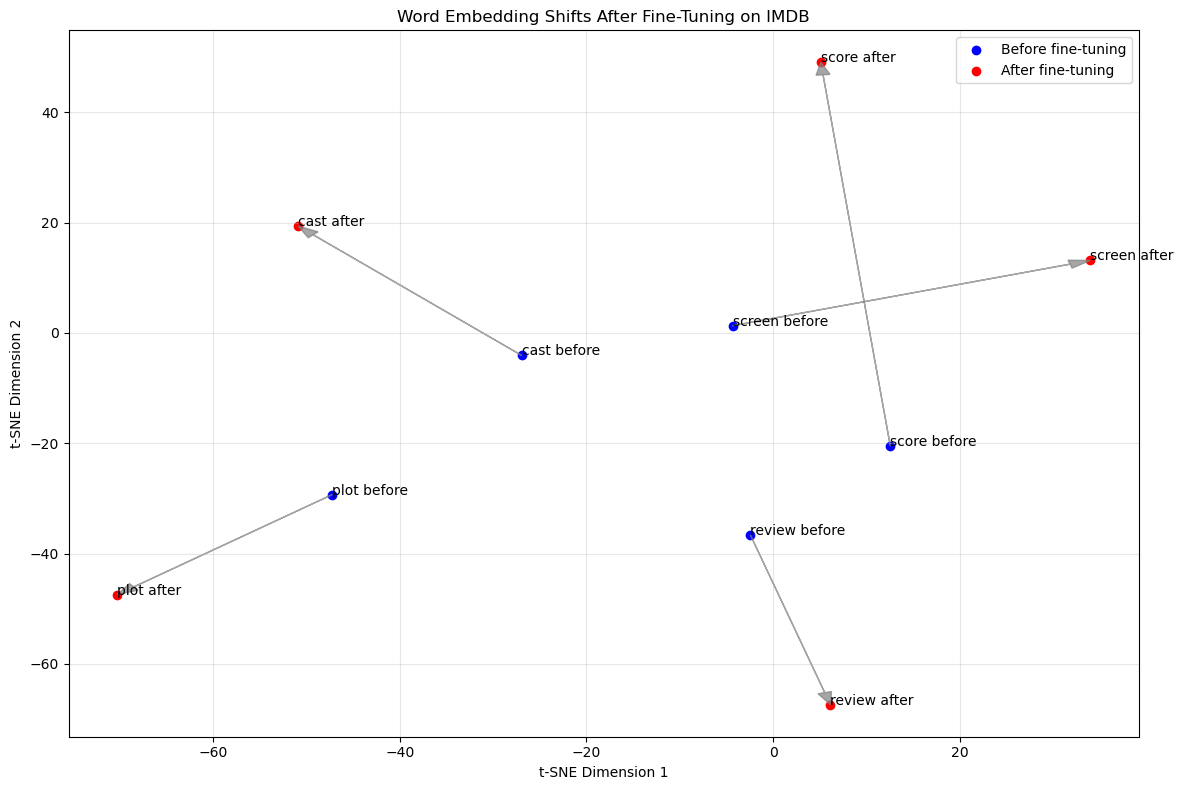

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

vectors = []
labels = []

for word in target_words:
    vectors.append(original_target_vectors[word])
    labels.append(f"{word} (before)")

    vectors.append(fine_tuned_model.wv[word])
    labels.append(f"{word} (after)")

vectors = np.array(vectors)

tsne = TSNE(
    n_components=2,
    perplexity=3,
    random_state=42,
    init="random"
)

vectors_2d = tsne.fit_transform(vectors)

plt.figure(figsize=(12, 8))

for i, word in enumerate(target_words):
    before_index = i * 2
    after_index = i * 2 + 1

    x1, y1 = vectors_2d[before_index]
    x2, y2 = vectors_2d[after_index]

    plt.scatter(x1, y1, color="blue")
    plt.scatter(x2, y2, color="red")

    plt.arrow(
        x1, y1,
        x2 - x1,
        y2 - y1,
        color="gray",
        alpha=0.7,
        head_width=1.5,
        length_includes_head=True
    )

    plt.text(x1, y1, f"{word} before")
    plt.text(x2, y2, f"{word} after")

plt.scatter([], [], color="blue", label="Before fine-tuning")
plt.scatter([], [], color="red", label="After fine-tuning")

plt.title("Word Embedding Shifts After Fine-Tuning on IMDB")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

# plt.savefig("../figures/embedding_shifts_tsne.png", dpi=300)
plt.show()

In [24]:
comparison_df.to_csv(r"C:\Users\samru\Study\Study_Abroad\Universities\SJSU\Semester3\Data_266_Generative_AI\Assignments\Assignment2\word2vec-imdb-transfer\neighbor_comparison.csv", index=False)
shift_df.to_csv(r"C:\Users\samru\Study\Study_Abroad\Universities\SJSU\Semester3\Data_266_Generative_AI\Assignments\Assignment2\word2vec-imdb-transfer\vector_shift_results.csv", index=False)

total_tokens = sum(len(review) for review in tokenized_reviews)
unique_words = len({
    word
    for review in tokenized_reviews
    for word in review
})

benchmark_df = pd.DataFrame([{
    "dataset": "IMDB",
    "num_reviews": len(tokenized_reviews),
    "total_tokens": total_tokens,
    "unique_words": unique_words,
    "google_model_vector_size": google_model.vector_size,
    "google_model_vocab_size": len(google_model.key_to_index),
    "imdb_vocab_size": len(fine_tuned_model.wv),
    "shared_vocab_size": len(shared_words),
    "dataset_load_time_seconds": load_time,
    "tokenization_time_seconds": tokenization_time,
    "google_model_load_time_seconds": model_load_time,
    "fine_tuning_time_seconds": fine_tuning_time
}])

benchmark_df.to_csv(r"C:\Users\samru\Study\Study_Abroad\Universities\SJSU\Semester3\Data_266_Generative_AI\Assignments\Assignment2\word2vec-imdb-transfer\benchmark_summary.csv", index=False)